# 02 - Análisis exploratorio con DuckDB (Ejercicio 4)

Preguntas planteadas (4.1) y consultas en `sql/04_eda.sql`. Todas las consultas se ejecutan con DuckDB
directamente sobre los Parquet (vistas `trips`, `trips_clean`, `zones`). Las gráficas se guardan en
`docs/img/` para la documentación (`docs/04_eda.md`).

| # | Dimensión | Pregunta |
|---|---|---|
| P1 | Temporal | ¿Cómo evoluciona el volumen mensual de viajes de cada tipo de taxi? |
| P2 | Temporal | ¿En qué horas y días se concentra la demanda? ¿Cambia el viaje entre semana y fin de semana? |
| P3 | Características | ¿Cómo es un viaje típico (distancia, duración, pasajeros)? |
| P4 | Características | ¿Cómo cambia la velocidad del tráfico a lo largo del día? |
| P5 | Yellow vs green | ¿Dónde se originan los viajes de cada tipo? |
| P6 | Yellow vs green | ¿En qué se diferencian económicamente? |
| P7 | Pago | ¿Cómo se distribuyen los métodos de pago y cambian en el tiempo? |
| P8 | Pago | ¿Qué propina se deja según el método de pago? |
| P9 | Pago | ¿Qué componentes forman el total pagado? |
| P10 | Distribuciones | ¿Cómo se distribuyen distancia y monto total? |
| P11 | Atípicos | ¿Qué valores atípicos e inconsistencias persisten tras la limpieza? |
| P12 | Características | ¿Qué peso tienen los viajes de aeropuerto? |

In [1]:
import sys
sys.path.insert(0, '../scripts')
from pathlib import Path
import lab_db
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

con = lab_db.conectar()
SQL = '../sql/04_eda.sql'
IMG = Path('../docs/img'); IMG.mkdir(parents=True, exist_ok=True)
COLORES = {'yellow': '#e0a800', 'green': '#2e8b57'}
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

def q(nombre):
    c = lab_db.consulta(nombre, SQL)
    df, s = lab_db.ejecutar(con, c.sql)
    print(f"[{nombre}] {c.meta.get('pregunta','')}  ({s:.2f} s)")
    return df

def guardar(fig, nombre):
    fig.savefig(IMG / f'{nombre}.png', bbox_inches='tight'); plt.show()

## P1 - Volumen mensual

[q4_01_viajes_por_mes] P1 (temporal) - Como evoluciona el volumen mensual de viajes de cada tipo de taxi?  (0.06 s)


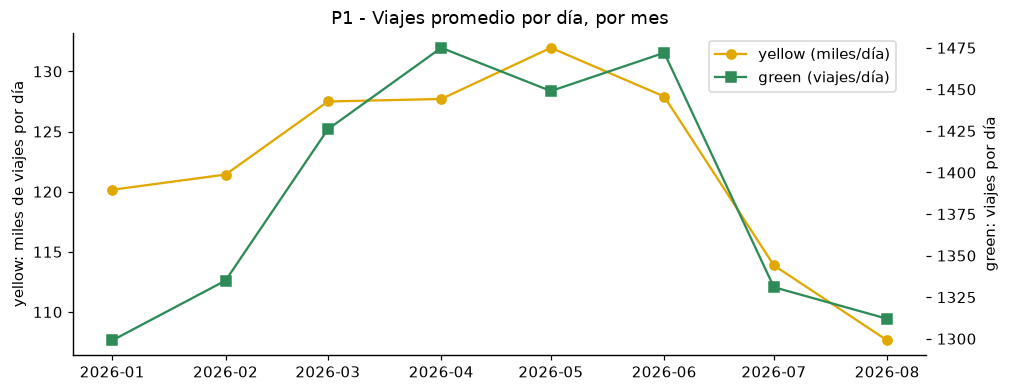

,taxi_type,anio,mes,viajes,viajes_por_dia,ingresos_musd,periodo
0,green,2026,1,40272,1299.0,0.97,2026-01-01
1,green,2026,2,37373,1335.0,0.91,2026-02-01
2,green,2026,3,44208,1426.0,1.10,2026-03-01
3,green,2026,4,44238,1475.0,1.12,2026-04-01
4,green,2026,5,44921,1449.0,1.16,2026-05-01
5,green,2026,6,44163,1472.0,1.16,2026-06-01
6,green,2026,7,41252,1331.0,1.08,2026-07-01
7,green,2026,8,40687,1312.0,1.08,2026-08-01
8,yellow,2026,1,3724889,120158.0,108.69,2026-01-01
9,yellow,2026,2,3399866,121424.0,102.38,2026-02-01


In [2]:
mes = q('q4_01_viajes_por_mes')
mes['periodo'] = pd.to_datetime(dict(year=mes.anio, month=mes.mes, day=1))
fig, ax = plt.subplots(figsize=(10, 3.8))
y, g = mes[mes.taxi_type == 'yellow'], mes[mes.taxi_type == 'green']
ax.plot(y.periodo, y.viajes_por_dia / 1e3, marker='o', color=COLORES['yellow'], label='yellow (miles/día)')
ax2 = ax.twinx()
ax2.plot(g.periodo, g.viajes_por_dia, marker='s', color=COLORES['green'], label='green (viajes/día)')
ax.set_ylabel('yellow: miles de viajes por día'); ax2.set_ylabel('green: viajes por día')
ax.set_title('P1 - Viajes promedio por día, por mes')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
guardar(fig, 'eda_p1_viajes_mes')
mes

## P2 - Demanda por hora y día de la semana

[q4_02_viajes_hora_dia] P2 (temporal) - En que horas y dias de la semana se concentra la demanda?  (0.49 s)


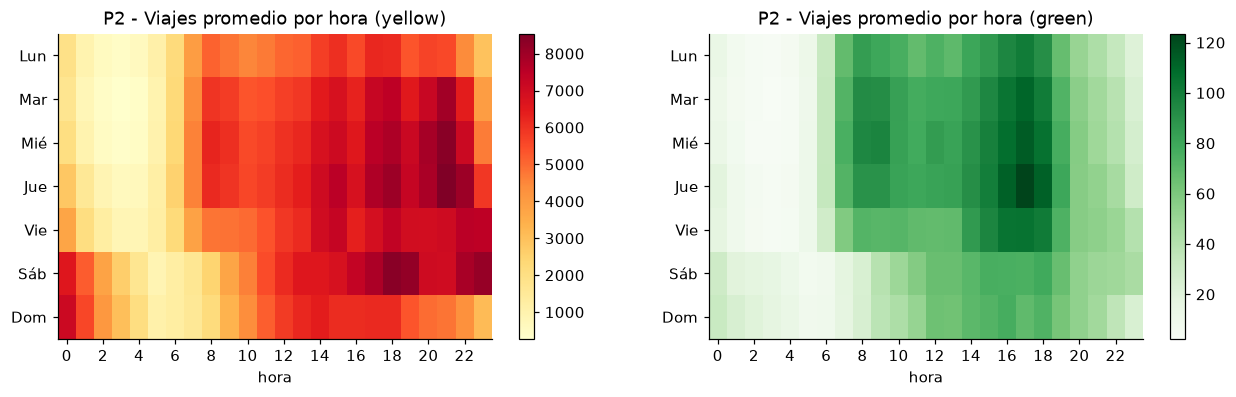

In [3]:
hd = q('q4_02_viajes_hora_dia')
fig, axes = plt.subplots(1, 2, figsize=(14, 3.6))
dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
for ax, tipo in zip(axes, ['yellow', 'green']):
    m = hd[hd.taxi_type == tipo].pivot(index='dow', columns='hora', values='viajes_promedio')
    im = ax.imshow(m, aspect='auto', cmap='YlOrRd' if tipo == 'yellow' else 'Greens')
    ax.set_yticks(range(7), dias); ax.set_xticks(range(0, 24, 2)); ax.set_xlabel('hora')
    ax.set_title(f'P2 - Viajes promedio por hora ({tipo})'); fig.colorbar(im, ax=ax)
guardar(fig, 'eda_p2_heatmap_hora_dia')

In [4]:
q('q4_03_perfil_horario')

[q4_03_perfil_horario] P2 (temporal) - Cual es la hora pico y la hora valle de cada tipo de taxi, entre semana y fin de semana?  (0.42 s)


,taxi_type,tipo_dia,hora_pico,pct_hora_pico,hora_valle,pct_hora_valle
0,green,entre semana,17,8.08,3,0.21
1,green,fin de semana,18,7.34,5,0.69
2,yellow,entre semana,21,6.57,3,0.45
3,yellow,fin de semana,18,6.21,5,0.83


In [5]:
q('q4_18_fin_de_semana_vs_semana')

[q4_18_fin_de_semana_vs_semana] P2 (temporal) - Cambian las caracteristicas del viaje entre semana y fin de semana?  (0.52 s)


,taxi_type,tipo_dia,viajes_por_dia,distancia_prom,duracion_prom,velocidad_prom,propina_pct_tarifa
0,yellow,entre semana,113872.0,3.50,18.2,10.5,14.39
1,yellow,fin de semana,116930.0,3.66,16.6,12.0,11.76
2,green,entre semana,1371.0,3.29,17.4,11.0,15.87
3,green,fin de semana,1033.0,3.49,15.8,12.5,14.89


## P3 / P4 - Características del viaje y velocidad

In [6]:
q('q4_04_caracteristicas_viaje').T

[q4_04_caracteristicas_viaje] P3 (caracteristicas) - Como son los viajes tipicos (distancia, duracion, pasajeros, velocidad)?  (2.89 s)


,0,1
taxi_type,yellow,green
viajes,27884915,309437
distancia_p50_mi,1.95,2.15
distancia_prom_mi,3.55,3.34
distancia_p95_mi,12.64,10.48
duracion_p50_min,14.2,13.3
duracion_prom_min,17.7,17.1
duracion_p95_min,44.1,43.0
velocidad_prom_mph,10.9,11.4
pasajeros_prom,1.25,1.32


[q4_05_velocidad_por_hora] P4 (caracteristicas/temporal) - Como cambia la velocidad del trafico a lo largo del dia?  (1.41 s)


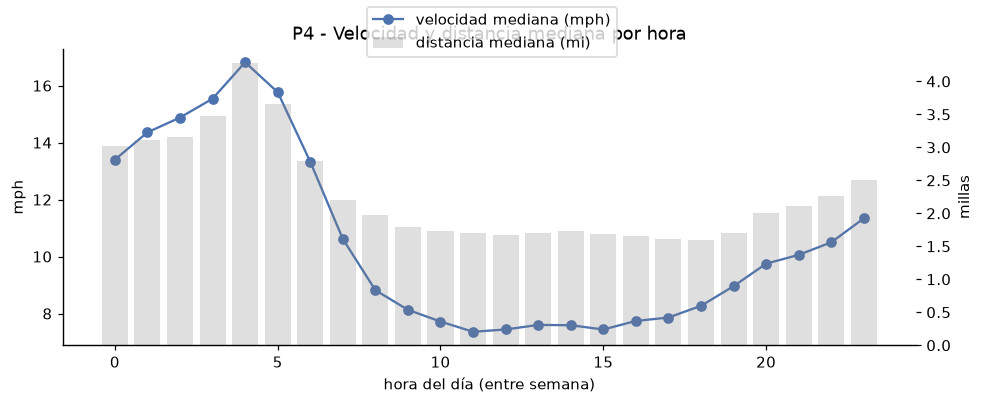

In [7]:
vel = q('q4_05_velocidad_por_hora')
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(vel.hora, vel.velocidad_mediana_mph, marker='o', color='#4c72b0', label='velocidad mediana (mph)')
ax2 = ax.twinx(); ax2.bar(vel.hora, vel.distancia_mediana_mi, alpha=0.25, color='gray', label='distancia mediana (mi)')
ax.set_xlabel('hora del día (entre semana)'); ax.set_ylabel('mph'); ax2.set_ylabel('millas')
ax.set_title('P4 - Velocidad y distancia mediana por hora'); fig.legend(loc='upper center')
guardar(fig, 'eda_p4_velocidad_hora')

In [8]:
q('q4_06_pasajeros')

[q4_06_pasajeros] P3 (caracteristicas) - Cuantos pasajeros viajan normalmente?  (0.13 s)


,taxi_type,pasajeros,viajes,pct
0,yellow,1,18069219,60.83
1,yellow,desconocido,7716688,25.98
2,yellow,2,2707073,9.11
3,yellow,3,612062,2.06
4,yellow,4,417054,1.40
5,yellow,0,91359,0.31
6,yellow,5,56383,0.19
7,yellow,6,33489,0.11
8,yellow,8,18,0.00
9,yellow,9,6,0.00


## P5 / P6 - Taxis amarillos vs verdes

[q4_07_borough_origen] P5 (yellow vs green) - En que boroughs se originan los viajes de cada tipo de taxi?  (0.44 s)


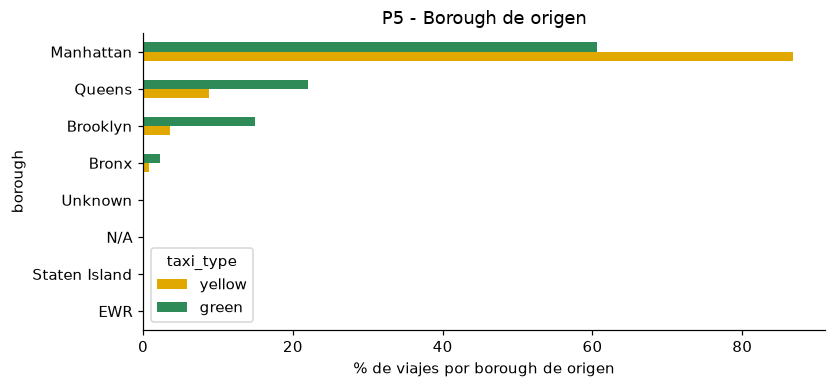

,taxi_type,borough,viajes,pct
0,yellow,Manhattan,24180526,86.72
1,yellow,Queens,2450756,8.79
2,yellow,Brooklyn,1002301,3.59
3,yellow,Bronx,215966,0.77
4,yellow,Unknown,28513,0.10
5,yellow,N/A,4196,0.02
6,yellow,Staten Island,2497,0.01
7,yellow,EWR,160,0.00
8,green,Manhattan,187600,60.63
9,green,Queens,68179,22.03


In [9]:
bor = q('q4_07_borough_origen')
b = bor.pivot(index='borough', columns='taxi_type', values='pct').fillna(0).sort_values('yellow')
fig, ax = plt.subplots(figsize=(8, 3.5))
b[['yellow', 'green']].plot.barh(ax=ax, color=[COLORES['yellow'], COLORES['green']])
ax.set_xlabel('% de viajes por borough de origen'); ax.set_title('P5 - Borough de origen')
guardar(fig, 'eda_p5_borough')
bor

In [10]:
q('q4_08_top_zonas')

[q4_08_top_zonas] P5 (yellow vs green) - Cuales son las zonas de origen mas frecuentes de cada tipo?  (0.52 s)


,taxi_type,borough,zone,viajes,pct,ranking
0,yellow,Manhattan,Upper East Side South,1241982,4.45,1
1,yellow,Manhattan,Midtown Center,1160544,4.16,2
2,yellow,Queens,JFK Airport,1109195,3.98,3
3,yellow,Manhattan,Upper East Side North,1101922,3.95,4
4,yellow,Manhattan,Penn Station/Madison Sq West,861047,3.09,5
5,yellow,Manhattan,Midtown East,856689,3.07,6
6,yellow,Manhattan,Times Sq/Theatre District,809165,2.90,7
7,yellow,Manhattan,Lincoln Square East,804034,2.88,8
8,green,Manhattan,East Harlem North,85408,27.60,1
9,green,Manhattan,East Harlem South,41348,13.36,2


In [11]:
q('q4_09_yellow_vs_green').T

[q4_09_yellow_vs_green] P6 (yellow vs green) - En que se diferencian economicamente los viajes amarillos y verdes?  (1.02 s)


,0,1
taxi_type,yellow,green
tarifa_prom,21.22,16.9
tarifa_por_milla_mediana,7.52,6.68
propina_prom,2.89,2.64
peajes_prom,0.55,0.3
congestion_prom,1.7,0.8
cbd_fee_prom,0.54,0.06
airport_fee_prom,0.13,0.0
total_prom,30.18,25.32
pct_tarifa_negociada,0.42,3.14


## P7 / P8 / P9 - Pago

[q4_10_tipo_pago] P7 (pago) - Como se distribuyen los metodos de pago y como cambian mes a mes?  (0.09 s)


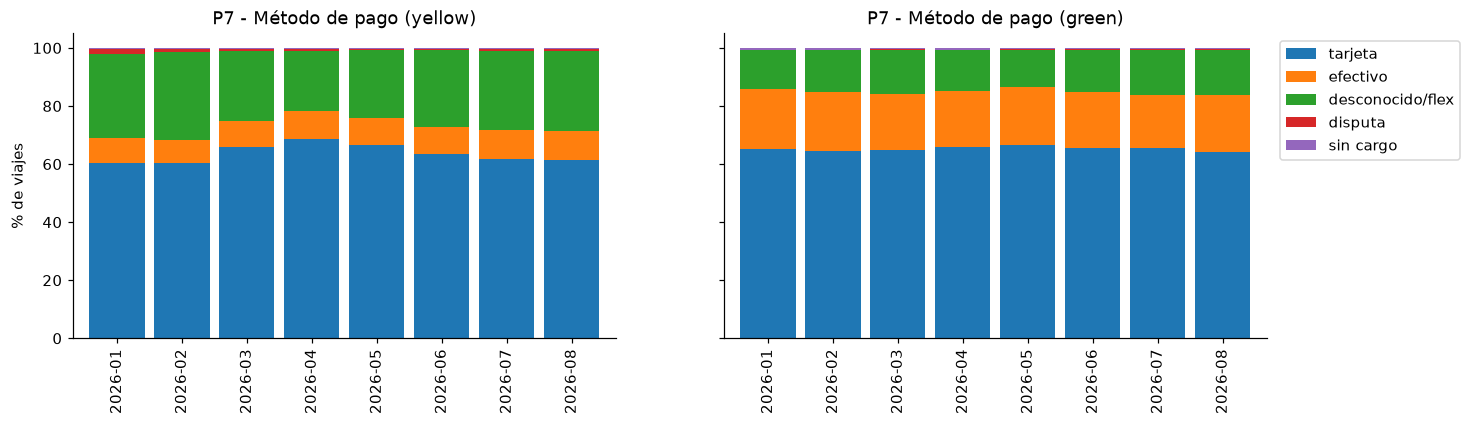

In [12]:
pago = q('q4_10_tipo_pago')
fig, axes = plt.subplots(1, 2, figsize=(14, 3.6), sharey=True)
for ax, tipo in zip(axes, ['yellow', 'green']):
    p = pago[pago.taxi_type == tipo].pivot_table(index=['anio', 'mes'], columns='metodo_pago', values='pct').fillna(0)
    p.index = [f'{a}-{m:02d}' for a, m in p.index]
    p[['tarjeta', 'efectivo', 'desconocido/flex', 'disputa', 'sin cargo']].plot.bar(stacked=True, ax=ax, width=0.85, legend=(tipo == 'green'))
    ax.set_title(f'P7 - Método de pago ({tipo})'); ax.set_ylabel('% de viajes')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
guardar(fig, 'eda_p7_metodo_pago')

In [13]:
q('q4_11_propina_por_pago')

[q4_11_propina_por_pago] P8 (pago) - Que porcentaje de propina se deja segun el metodo de pago?  (0.48 s)


,taxi_type,metodo_pago,viajes,pct_con_propina,propina_pct_tarifa,propina_prom
0,yellow,tarjeta,18325295,91.15,21.63,4.24
1,yellow,desconocido/flex,6889119,8.33,1.57,0.41
2,yellow,efectivo,2508720,0.01,0.00,0.00
3,yellow,disputa,109991,0.02,0.01,0.00
4,yellow,sin cargo,51790,0.02,0.00,0.00
5,green,tarjeta,205942,91.74,21.15,3.79
6,green,efectivo,60413,0.00,0.00,0.00
7,green,desconocido/flex,42524,17.19,8.05,0.84
8,green,sin cargo,389,0.26,0.03,0.01
9,green,disputa,169,0.00,0.00,0.00


[q4_12_composicion_total] P9 (pago) - Que componentes forman el monto total pagado?  (0.52 s)


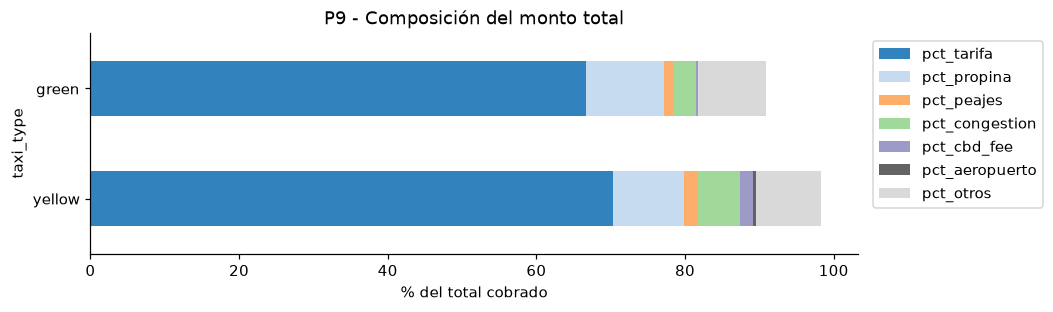

,pct_tarifa,pct_propina,pct_peajes,pct_congestion,pct_cbd_fee,pct_aeropuerto,pct_otros
taxi_type,,,,,,,
yellow,70.31,9.57,1.83,5.64,1.80,0.42,8.74
green,66.72,10.43,1.18,3.17,0.25,0.00,9.20


In [14]:
comp = q('q4_12_composicion_total').set_index('taxi_type')
fig, ax = plt.subplots(figsize=(9, 2.6))
comp.plot.barh(stacked=True, ax=ax, colormap='tab20c')
ax.set_xlabel('% del total cobrado'); ax.set_title('P9 - Composición del monto total')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
guardar(fig, 'eda_p9_composicion_total')
comp

## P10 - Distribuciones

[q4_13_distribucion_distancia] P10 (distribuciones) - Como se distribuye la distancia de los viajes?  (0.50 s)


[q4_14_distribucion_tarifa] P10 (distribuciones) - Como se distribuye el monto total pagado?  (0.43 s)


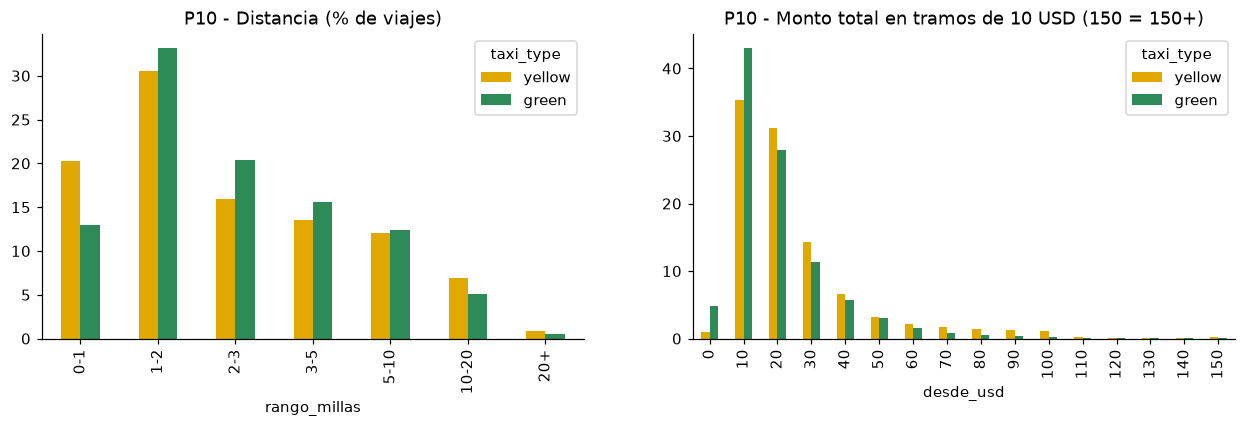

In [15]:
dist = q('q4_13_distribucion_distancia'); tar = q('q4_14_distribucion_tarifa')
fig, axes = plt.subplots(1, 2, figsize=(14, 3.6))
d = dist.pivot(index='rango_millas', columns='taxi_type', values='pct').loc[['0-1','1-2','2-3','3-5','5-10','10-20','20+']]
d[['yellow', 'green']].plot.bar(ax=axes[0], color=[COLORES['yellow'], COLORES['green']]); axes[0].set_title('P10 - Distancia (% de viajes)')
t = tar.pivot(index='desde_usd', columns='taxi_type', values='pct')
t[['yellow', 'green']].plot.bar(ax=axes[1], color=[COLORES['yellow'], COLORES['green']]); axes[1].set_title('P10 - Monto total en tramos de 10 USD (150 = 150+)')
guardar(fig, 'eda_p10_distribuciones')

## P11 - Atípicos e inconsistencias

In [16]:
q('q4_15_atipicos_iqr').T

[q4_15_atipicos_iqr] P11 (atipicos) - Cuantos viajes limpios siguen siendo atipicos segun el criterio IQR?  (5.10 s)


,0,1
taxi_type,yellow,green
lim_sup_distancia,8.33,7.37
pct_atip_distancia,10.8,10.07
lim_sup_duracion,42.7,37.9
pct_atip_duracion,5.44,6.82
lim_sup_total,59.77,51.25
pct_atip_total,8.5,6.59
lim_sup_usd_milla,16.09,12.26
pct_atip_usd_milla,5.15,4.5


In [17]:
q('q4_16_inconsistencias_monto')

[q4_16_inconsistencias_monto] P11 (inconsistencias) - El total cobrado coincide con la suma de sus componentes?  (0.47 s)


,taxi_type,viajes,total_no_cuadra,pct_no_cuadra,efectivo_con_propina_registrada,velocidad_mayor_80mph
0,yellow,29703355,10893972,36.676,183,7987
1,green,337114,66969,19.865,0,1158


In [18]:
q('q4_19_inconsistencia_por_proveedor')

[q4_19_inconsistencia_por_proveedor] P11 (inconsistencias) - La diferencia entre el total y sus componentes depende del proveedor del taximetro?  (0.48 s)


,taxi_type,proveedor,pago,viajes,pct_no_cuadra,diferencia_mediana_usd
0,yellow,2 Curb Mobility,tarjeta,14592874,0.1,2.50
1,yellow,2 Curb Mobility,flex/desconocido,6761917,88.2,2.50
2,yellow,1 Creative Mobile,tarjeta,4028246,82.3,-3.25
3,yellow,2 Curb Mobility,efectivo,2217837,0.2,2.50
4,yellow,1 Creative Mobile,flex/desconocido,895381,98.3,4.08
5,yellow,1 Creative Mobile,efectivo,447521,93.2,-3.25
6,yellow,7 Helix,tarjeta,319888,43.5,1.00
7,yellow,2 Curb Mobility,otro,237146,0.2,0.00
8,yellow,1 Creative Mobile,otro,95923,82.6,-3.25
9,yellow,6 Myle,flex/desconocido,59390,100.0,24.74


## P12 - Aeropuertos

In [19]:
q('q4_17_aeropuertos')

[q4_17_aeropuertos] P12 (caracteristicas) - Que peso tienen los viajes a/desde aeropuertos y cuanto cuestan?  (1.31 s)


,taxi_type,categoria,viajes,pct_viajes,distancia_prom,total_prom,pct_ingresos
0,yellow,aeropuerto,2273124,8.15,13.09,77.96,21.06
1,yellow,otros,25611791,91.85,2.70,25.94,78.94
2,green,aeropuerto,10641,3.44,7.35,48.39,6.57
3,green,otros,298796,96.56,3.20,24.50,93.43


## Hallazgos principales (4.5)

Ver la discusión completa en `docs/04_eda.md`.

1. **El taxi verde ya no es un taxi de "outer boroughs":** 60.6% de sus viajes inicia en Manhattan
   (41% solo en East Harlem), mientras que el amarillo concentra 86.7% en Manhattan y 8% de sus viajes
   (21% de sus ingresos) son de aeropuerto.
2. **La velocidad del tráfico se desploma de día:** la mediana baja de ~16.8 mph a las 4 a.m. a ~7.4 mph
   entre las 11 y 15 h; la duración mediana casi no cambia porque los viajes de día son más cortos.
3. **Los registros de pago no son homogéneos entre proveedores:** 36.7% de los totales amarillos no
   cuadran con sus componentes; el proveedor 1 registra sistemáticamente −3.25 USD (congestión + CBD
   incluidos dentro de `extra`) y los viajes flex del proveedor 2 cobran +2.50 USD de congestión sin
   registrarla. Además, la propina en efectivo es 0 (no se registra): el 21.6% de propina con tarjeta
   no puede extrapolarse a todos los viajes.